F1 Circuit Complexity Index
--------
Formula 1 is the peak of motorsport where only the best drivers from around the world are allowed behind the wheel and onto the track. Each track is unique and has its own set of technical and physical challenges the drivers must adapt to. This analysis looks to develop a composite indicator designed to quantify the difficulty of all circuits.

## Finding the data

To create this index I am going to need to combine a few datasets. I will need data about the circuits that includes their length, number of corners, height elevation, top speed etc. To better show how difficult a track is I will also seek out a dataset containing all safety cars deployed and their reason for each track. 

I am interested to see how the safety car dataset will influence the result as you could argue that a track that has more safety cars is more difficult. Finally I will attempt to find a dataset containing time penalties given to drivers, specifically track limit penalties. This occurs when all four tyres cross the white line markings of the track edge, possibly indicating a higher difficulty.


- Data Sources
1. <a href="https://mintlify.wiki/TracingInsights/RaceData/introduction">RaceData</a>
2. <a href="https://www.kaggle.com/datasets/kishan305/formula-1-circuits-1950-present">Kaggle - Formula 1 Circuits (1950 - Present)</a>


**Race Data** is a comprehensive Formula 1 race data from 1950 to present. They provide 18 data tables that will provide me with safety car, red flags and fatal accident data.

**Kaggle** Although RaceData does provide a dataset on all circuits I have opted to use this kaggle dataset as there is more technical information about each track in it.


TODO: Talk about low amount of data rows but lots of data points, I have captured nearly all of the circuits and it is about data quality not quantity

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

circuit_metrics = pd.read_csv("data/all_f1_circuits.csv")
circuit_metrics.head()

,Circuit,City,Country,Track Length (km),Turns,Direction,Circuit Type,First Grand Prix,Last Grand Prix,Races,Best Lap Timing,Best Lap Driver,Best Lap Year,Best Lap Time
0,Brands Hatch,Fawkham,United Kingdom,4.207,9,Clockwise,Race,1964 British Grand Prix,1986 British Grand Prix,14,1:09.593,Nigel Mansell,1986,69.593
1,AVUS,Berlin,Germany,8.300,4,Anti clockwise,Road,1959 German Grand Prix,1959 German Grand Prix,1,2:04.500,Tony Brooks,1959,124.500
2,Autodromo Internazionale Enzo e Dino Ferrari,Imola,Italy,4.909,19,Anti clockwise,Race,1980 Italian Grand Prix,2025 Emilia Romagna Grand Prix,32,1:15.484,Lewis Hamilton,2020,75.484
3,Autódromo Juan y Oscar Gálvez,Buenos Aires,Argentina,4.259,19,Clockwise,Race,1953 Argentine Grand Prix,1998 Argentine Grand Prix,20,1:11.220,Emerson Fittipaldi,1973,71.220
4,Autodromo Internazionale del Mugello,Scarperia e San Piero,Italy,5.245,15,Clockwise,Race,2020 Tuscan Grand Prix,2020 Tuscan Grand Prix,1,1:18.833,Lewis Hamilton,2020,78.833


In [253]:
safety_cars = pd.read_csv("data/safety_cars.csv")
safety_cars.head()

,Race,Cause,Deployed,Retreated,FullLaps
0,1973 Canadian Grand Prix,Accident,33,39.0,5
1,1993 Brazilian Grand Prix,Accident/Rain,29,38.0,8
2,1993 British Grand Prix,Stranded car,38,40.0,1
3,1994 San Marino Grand Prix,Accident,1,6.0,4
4,1995 Belgian Grand Prix,Rain,28,33.0,4


In [254]:
red_flags = pd.read_csv("data/red_flags.csv")
red_flags.head()

,Race,Lap,Resumed,Incident,Excluded
0,1950 Indianapolis 500,138,N,Rain.,NaN
1,1971 Canadian Grand Prix,64,N,Mist.,NaN
2,1973 British Grand Prix,2,Y,"Crash involving Jody Scheckter, Jean-Pierre Be...","Jody Scheckter, Jean-Pierre Beltoise, George F..."
3,1974 Brazilian Grand Prix,32,N,Rain.,NaN
4,1975 Spanish Grand Prix,29,N,Crash of Rolf Stommelen which killed five spec...,NaN


In [255]:
fatal_accidents_drivers = pd.read_csv("data/fatal_accidents_drivers.csv")
fatal_accidents_drivers.head()

,Driver,Age,Date Of Accident,Event,Car,Session
0,Cameron Earl,29.0,6/18/52,NaN,ERA,Test
1,Chet Miller,50.0,5/15/53,1953 Indianapolis 500,Kurtis Kraft,Practice
2,Charles de Tornaco,26.0,9/18/53,1953 Modena Grand Prix,Ferrari,Practice
3,Onofre Marimón,30.0,7/31/54,1954 German Grand Prix,Maserati,Practice
4,Mario Alborghetti,26.0,4/11/55,1955 Pau Grand Prix,Maserati,Race


In [256]:
## Added during selecting variables
circuit_info = pd.read_csv("data/circuits.csv")
circuit_info.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


Selecting Variables
------

To select my variables I am using excel to view the raw data. What is referenced will be from those observations but I will show what I am talking about through visualization here. As the data is coming from 2 different sources there are likely some discrepancies hidden in them. For example the above head of fatal_accidents_driver and red_flags have NaN values, some tracks are describe using a slightly different name. 


Something important I have to consider to ensure this index is accurate is what is the cut off year before I start excluding race data from my data set. I think this because if you look back at what the level of safety standards were back in 1950 to 1980 they were basically non-existent. Only until the mid 90s did the FIA enforce strict rules on the teams and cars. With this in mind and before fully getting into this data i think it would be best to use race data from the year 2000 until present.

In [257]:
master_data = []

#### All Circuits

Although the race name is not important for the index result, it will be a key part of linking the data together. Something I immediately noticed is that all_f1_circuits.csv  uses the proper circuit name and the others use a format of - $Year + Country + Grand Prix$. In all_circuits_f1 I am given the city and the country but using this as a link will fail on races like British and Italian as these are now the country names. To get passed this im going to use the circuits data provided by RaceData which contains the name of the circuit. 

By merging these two together I can also include the circuitId provided by circuits.csv to then use as a link to all the other datasets from RaceData making it much easier to add data to my problem.

In [258]:
# sorted by name to show how they line up
sorted_metrics = circuit_metrics.sort_values(by='Circuit')
sorted_info = circuit_info.sort_values(by='name')

print("(Kaggle) all_f1_circuits.csv description of track")
print(list(sorted_metrics.Circuit.values))
print(f"Length - {len(sorted_metrics)}")
print("\n(RaceData) circuits.csv description of track")
print(list(sorted_info.name.values))
print(f"Length - {len(sorted_info)}")

(Kaggle) all_f1_circuits.csv description of track
['AVUS', 'Adelaide Street Circuit', 'Ain-Diab Circuit', 'Aintree Motor Racing Circuit', 'Algarve International Circuit', 'Anderstorp Raceway', 'Autodromo Internazionale Enzo e Dino Ferrari', 'Autodromo Internazionale del Mugello', 'Autodromo Nazionale Monza', 'Autódromo Hermanos Rodríguez', 'Autódromo Internacional Nelson Piquet', 'Autódromo José Carlos Pace', 'Autódromo Juan y Oscar Gálvez', 'Autódromo do Estoril', 'Bahrain International Circuit', 'Baku City Circuit', 'Brands Hatch', 'Buddh International Circuit', 'Bugatti Circuit', 'Caesars Palace', 'Canadian Tire Motorsport Park', 'Charade Circuit', 'Circuit Bremgarten', 'Circuit Gilles Villeneuve', 'Circuit Mont-Tremblant', 'Circuit Park Zandvoort', 'Circuit Paul Ricard', 'Circuit Zolder', 'Circuit de Barcelona-Catalunya', 'Circuit de Monaco', 'Circuit de Nevers Magny-Cours', 'Circuit de Spa-Francorchamps', 'Circuit of the Americas', 'Circuito da Boavista', 'Circuito de Jerez', 'Cir

There is 1 race missing from the all_f1_circuits and also some of the circuits still come under a different name. I will find the ones that match and review the misaligned ones using python sets. 

In [259]:
# first I want to check how many of the circuit names match between the datasets
matching_circuits = []
match_count = 0
bad_count = 0
print(len(circuit_metrics))
print(len(circuit_info))

# create sets of the unique names in both columns
circuit_names1 = set(circuit_metrics['Circuit'])
circuit_names2 = set(circuit_info['name']) # Replace with your actual column name

# using intersection to get a list of matching items between the sets - https://www.w3schools.com/python/ref_set_intersection.asp
matches = circuit_names1.intersection(circuit_names2)
metrics_mismatches = circuit_names1.difference(circuit_names2)
info_mismatches = circuit_names2.difference(circuit_names1)

print(metrics_mismatches)
print(info_mismatches)
print(f"Matches: {len(matches)}")
print(f"Circuit Metrics: {len(metrics_mismatches)}")
print(f"Circuit Info: {len(info_mismatches)}")

77
78
{'Lusail International Circuit', 'Pedralbes Circuit', 'Algarve International Circuit', 'Watkins Glen International', 'Kyalami Racing Circuit', 'Autodromo Internazionale Enzo e Dino Ferrari', 'Anderstorp Raceway', 'Phoenix Street Circuit', 'Caesars Palace', 'Canadian Tire Motorsport Park', 'Melbourne Grand Prix Circuit', 'Bugatti Circuit', 'Circuito de Montjuïc', 'Autodromo Nazionale Monza', 'Ain-Diab Circuit', 'Korea International Circuit', 'Circuit Zolder', 'Circuito de Monsanto', 'Aintree Motor Racing Circuit', 'Circuito del Jarama'}
{'Watkins Glen', 'Losail International Circuit', 'Ain Diab', 'Madring', 'Autodromo Nazionale di Monza', 'Aintree', 'Mosport International Raceway', 'Autódromo Internacional do Algarve', 'Circuit de Pedralbes', 'Monsanto Park Circuit', 'Le Mans', 'Zolder', 'Albert Park Grand Prix Circuit', 'Kyalami', 'Las Vegas Strip Street Circuit', 'Montjuïc', 'Autodromo Enzo e Dino Ferrari', 'Korean International Circuit', 'Scandinavian Raceway', 'Phoenix street 

In [260]:
print(sorted(metrics_mismatches))
print(sorted(info_mismatches))

['Ain-Diab Circuit', 'Aintree Motor Racing Circuit', 'Algarve International Circuit', 'Anderstorp Raceway', 'Autodromo Internazionale Enzo e Dino Ferrari', 'Autodromo Nazionale Monza', 'Bugatti Circuit', 'Caesars Palace', 'Canadian Tire Motorsport Park', 'Circuit Zolder', 'Circuito de Monsanto', 'Circuito de Montjuïc', 'Circuito del Jarama', 'Korea International Circuit', 'Kyalami Racing Circuit', 'Lusail International Circuit', 'Melbourne Grand Prix Circuit', 'Pedralbes Circuit', 'Phoenix Street Circuit', 'Watkins Glen International']
['Ain Diab', 'Aintree', 'Albert Park Grand Prix Circuit', 'Autodromo Enzo e Dino Ferrari', 'Autodromo Nazionale di Monza', 'Autódromo Internacional do Algarve', 'Circuit de Pedralbes', 'Jarama', 'Korean International Circuit', 'Kyalami', 'Las Vegas Strip Street Circuit', 'Le Mans', 'Losail International Circuit', 'Madring', 'Monsanto Park Circuit', 'Montjuïc', 'Mosport International Raceway', 'Phoenix street circuit', 'Scandinavian Raceway', 'Watkins Gle

Looking at the circuits the easiest thing I can do here is create a mapping dict that I can refer back to in a loop to get the correct circuit. Looking through the lists I have found that Madring is the missing circuit. I have opted to exclude it from the data.

In [261]:
# all_f1_circuit.csv as key | circuits.csv as value
# to get this mapping data I copied the above lists the I generated and asked an LLM to find the matching sets and produce a map.
circuit_mapping = {
    'Ain-Diab Circuit': 'Ain Diab',
    'Aintree Motor Racing Circuit': 'Aintree',
    'Algarve International Circuit': 'Autódromo Internacional do Algarve',
    'Anderstorp Raceway': 'Scandinavian Raceway',
    'Autodromo Internazionale Enzo e Dino Ferrari': 'Autodromo Enzo e Dino Ferrari',
    'Autodromo Nazionale Monza': 'Autodromo Nazionale di Monza',
    'Bugatti Circuit': 'Le Mans',
    'Caesars Palace': 'Las Vegas Strip Street Circuit', 
    'Canadian Tire Motorsport Park': 'Mosport International Raceway',
    'Circuit Zolder': 'Zolder',
    'Circuito de Monsanto': 'Monsanto Park Circuit',
    'Circuito de Montjuïc': 'Montjuïc',
    'Circuito del Jarama': 'Jarama',
    'Korea International Circuit': 'Korean International Circuit',
    'Kyalami Racing Circuit': 'Kyalami',
    'Lusail International Circuit': 'Losail International Circuit',
    'Melbourne Grand Prix Circuit': 'Albert Park Grand Prix Circuit',
    'Pedralbes Circuit': 'Circuit de Pedralbes',
    'Phoenix Street Circuit': 'Phoenix street circuit',
    'Watkins Glen International': 'Watkins Glen'
}

In [262]:
uncombined_metrics = circuit_metrics[['Circuit', 'Track Length (km)', 'Turns', 'Direction', 'Circuit Type']]
uncombined_info = circuit_info[['circuitId', 'name', 'country']]
combined_data = []

for index_m, row_m in uncombined_metrics.iterrows():
    circuit_name = row_m['Circuit']
    
    target_search_name = circuit_mapping.get(circuit_name, circuit_name)
    
    found = False
    for index_i, row_i in uncombined_info.iterrows():
        if row_i['name'] == target_search_name:
            combined_row = {
                'Circuit': circuit_name,
                'Track Length (km)': row_m['Track Length (km)'],
                'Turns': row_m['Turns'],
                'Direction': row_m['Direction'],
                'Circuit Type': row_m['Circuit Type'],
                'circuitId': row_i['circuitId'],
                'country': row_i['country']
            }
            master_data.append(combined_row)
            found = True
            # print(f"match: {circuit_name} - {target_search_name}")
            break
            
    # if not found:
        # print(f"no match: {circuit_name} - looking for '{target_search_name}')")

combined_circuits = pd.DataFrame(master_data)
combined_circuits.head()
print(len(combined_circuits))

77


#### Now that I have combined these two datasets the rest can be combined using circuitId taken from the RaceData dataset

#### Safety Cars

In [263]:
safety_cars.head()

,Race,Cause,Deployed,Retreated,FullLaps
0,1973 Canadian Grand Prix,Accident,33,39.0,5
1,1993 Brazilian Grand Prix,Accident/Rain,29,38.0,8
2,1993 British Grand Prix,Stranded car,38,40.0,1
3,1994 San Marino Grand Prix,Accident,1,6.0,4
4,1995 Belgian Grand Prix,Rain,28,33.0,4


To my surprise, even though the safety_cars.csv comes from the same source that uses circuitId, the only useful variable to match is the race name. This race name does not match what I have just done above...

This dataset contains 3 data points

**Cause**: Why a safety car was deployed on track<br>
**Deployed**: The lap which the safety car left the pit lane<br>
**FullLaps**: Number of full laps around the circuit before safety car returned<br>

All I care about is the amount of times a safety car was called on track. So I need to filter out the tra

In [264]:
# TODO: pull out year and add it as a column to safety cars. Will allow me to group by year >= 2000
years = []
for index, row in safety_cars.iterrows():
  year = row.Race.split()[0]
  years.append(year)

# add years to safety cars, used for filtering later
safety_cars['Year'] = years
print(f"Length of safety cars df - {len(safety_cars)}")
print(f"Length of extracted years - {len(years)}")

# print(safety_cars.head())

filtered_safety_cars = safety_cars[safety_cars['Year'] >= '2000']
filtered_safety_cars['GP_Name'] = safety_cars['Race'].apply(lambda x: " ".join(x.split()[1:]))

print(f"Length of filtered safety cars df (Year >= 2000) - {len(filtered_safety_cars)}")

# Removing columns that wont be used 
filtered_safety_cars.drop(columns=['Cause', 'Deployed', 'FullLaps', 'Retreated', 'Race'], inplace=True)

print(filtered_safety_cars.head())



Length of safety cars df - 366
Length of extracted years - 366
Length of filtered safety cars df (Year >= 2000) - 343
    Year                GP_Name
23  2000  Australian Grand Prix
24  2000    Austrian Grand Prix
25  2000      German Grand Prix
26  2000      German Grand Prix
27  2000     Belgian Grand Prix


Now that I have pulled the year out of each row and added it as a new column, I will be able to filter out races from certain years. Next I want to pull out the race name and count the occurrence and that will be the important information from safety cars.

In [265]:
safety_cars_count = filtered_safety_cars.groupby('GP_Name').size().reset_index(name='Safety_Car_Count')
print(safety_cars_count)

                      GP_Name  Safety_Car_Count
0        Abu Dhabi Grand Prix                 6
1       Australian Grand Prix                29
2         Austrian Grand Prix                13
3       Azerbaijan Grand Prix                 9
4          Bahrain Grand Prix                 9
5          Belgian Grand Prix                18
6        Brazilian Grand Prix                20
7          British Grand Prix                21
8         Canadian Grand Prix                24
9          Chinese Grand Prix                13
10           Dutch Grand Prix                 6
11           Eifel Grand Prix                 1
12  Emilia Romagna Grand Prix                 4
13        European Grand Prix                 4
14          French Grand Prix                 2
15          German Grand Prix                11
16       Hungarian Grand Prix                 7
17         Italian Grand Prix                10
18        Japanese Grand Prix                15
19          Korean Grand Prix           

Now I have a list of all circuits that have had a safety car deployed between the year 2000 and present. 

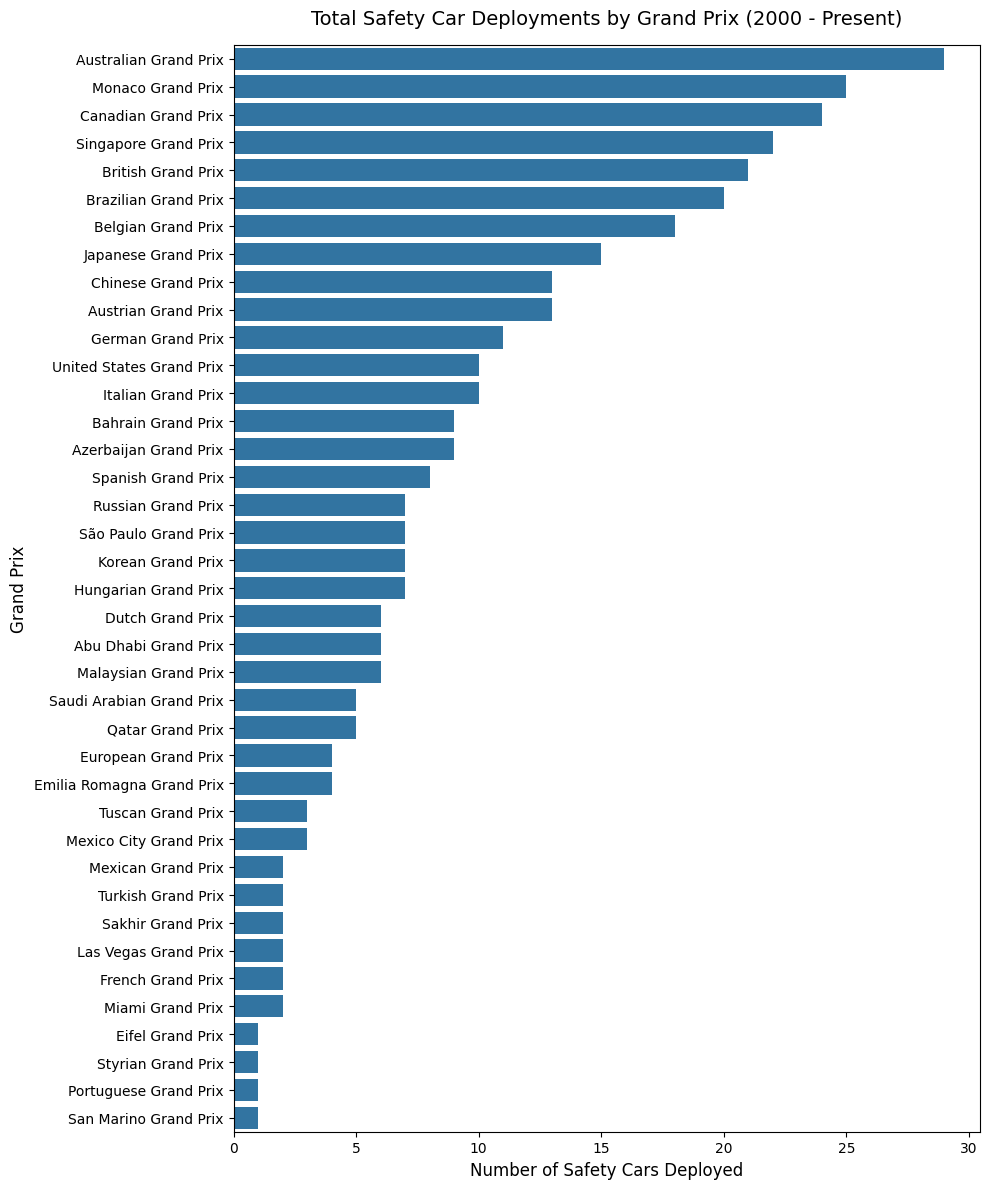

In [266]:
safety_cars_count = safety_cars_count.sort_values(by='Safety_Car_Count', ascending=False)

# 5. Create the plot
plt.figure(figsize=(10, 12))  # Taller height ensures every race name has room to breathe
sns.barplot(
    data=safety_cars_count, 
    x='Safety_Car_Count', 
    y='GP_Name', 
)

# 6. Customize labels and title so it looks professional
plt.title('Total Safety Car Deployments by Grand Prix (2000 - Present)', fontsize=14, pad=15)
plt.xlabel('Number of Safety Cars Deployed', fontsize=12)
plt.ylabel('Grand Prix', fontsize=12)

# Adjust layout automatically so no labels are truncated
plt.tight_layout()
plt.show()

Looking at this bar chart and being an F1 fan myself, I can see that races that have been in the race schedule for almost every season since 1950 have a quite have safety car deployment rate. Some of these races like the Miami Grand Prix only started happening within the last few years.


To balancing this out across all races I will get an average safety car count per circuit based on how many times it was raced since 2000
$$\text{Safety Car Rate} = \frac{\text{Total Safety Cars}}{\text{Total Races Hosted}}$$

I will need to use the races.csv to count how many times a track has been raced since 2000

In [267]:
races = pd.read_csv("data/races.csv")
races.head()
print(f"Count - {len(races)}")

Count - 1171


In [268]:
filtered_races = races[races['year'] >= 2000].copy()
print(f"Count - {len(filtered_races)}")

Count - 525


In [269]:

# Count the circuitIds and created a new column called Races_Hosted to hold this number
races_hosted_counts = filtered_races.groupby('circuitId').size().reset_index(name='Races_Hosted')
print(races_hosted_counts.head())
# Create new column that matches GP_Name in safety cars, safety cars will have cirucitId have this merge from races
races['Race_Match'] = races['year'].astype(str) + " " + races['name']
races.head()

   circuitId  Races_Hosted
0          1            25
1          2            18
2          3            22
3          4            27
4          5             9


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time,Race_Match
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Australian Grand Prix
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Malaysian Grand Prix
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Chinese Grand Prix
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Bahrain Grand Prix
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Spanish Grand Prix


In [281]:
# 1. Convert your Year column to an integer so it matches races['year']
filtered_safety_cars['Year'] = filtered_safety_cars['Year'].astype(int)

# 2. Merge on BOTH columns simultaneously to grab the circuitId!
sc_with_id = pd.merge(
    filtered_safety_cars,
    races[['year', 'name', 'circuitId']],
    left_on=['Year', 'GP_Name'],
    right_on=['year', 'name'],
    how='left'
)

# 3. Group by the circuitId to count safety cars per track
sc_counts = sc_with_id.groupby('circuitId').size().reset_index(name='Safety_Car_Count')

# 4. Merge this with the races_hosted_counts table you created in the previous step
safety_car_count_master = pd.merge(races_hosted_counts, sc_counts, on='circuitId', how='left')

# 5. Fill tracks that had 0 safety cars with 0 instead of NaN
safety_car_count_master['Safety_Car_Count'] = safety_car_count_master['Safety_Car_Count'].fillna(0)

# 6. Calculate your unbiased Average Safety Car Rate per Race!
safety_car_count_master['Safety_Car_Rate'] = safety_car_count_master['Safety_Car_Count'] / safety_car_count_master['Races_Hosted']

# Inspect your beautiful, completed safety car metrics!
print(safety_car_count_master.sort_values(by='Safety_Car_Rate', ascending=False).head(10))

    circuitId  Races_Hosted  Safety_Car_Count  Safety_Car_Rate
33         76             1               3.0         3.000000
25         35             4               7.0         1.750000
14         15            17              22.0         1.294118
0           1            25              29.0         1.160000
17         18            26              27.0         1.038462
34         77             5               5.0         1.000000
26         39             6               6.0         1.000000
15         16             2               2.0         1.000000
6           7            24              24.0         1.000000
35         78             5               5.0         1.000000


#### Red Flags

In [282]:
# 1. Extract the year as an integer
red_flags['Year'] = red_flags['Race'].str.split().str[0].astype(int)

# 2. Filter for races from 2000 to present
modern_rf = red_flags[red_flags['Year'] >= 2000].copy()

# 3. Clean the race name to match your other datasets
# Example: "2001 Belgian Grand Prix" -> "Belgian Grand Prix"
modern_rf['Grand_Prix'] = modern_rf['Race'].apply(lambda x: " ".join(x.split()[1:]))

for index, row in modern_rf.iterrows():
    print(f"{row.Race} - {row.Grand_Prix}")

2000 Monaco Grand Prix - Monaco Grand Prix
2001 German Grand Prix - German Grand Prix
2001 Belgian Grand Prix - Belgian Grand Prix
2003 Brazilian Grand Prix - Brazilian Grand Prix
2007 European Grand Prix - European Grand Prix
2009 Malaysian Grand Prix - Malaysian Grand Prix
2010 Korean Grand Prix - Korean Grand Prix
2011 Monaco Grand Prix - Monaco Grand Prix
2011 Canadian Grand Prix - Canadian Grand Prix
2012 Malaysian Grand Prix - Malaysian Grand Prix
2013 Monaco Grand Prix - Monaco Grand Prix
2014 British Grand Prix - British Grand Prix
2014 Japanese Grand Prix - Japanese Grand Prix
2014 Japanese Grand Prix - Japanese Grand Prix
2016 Australian Grand Prix - Australian Grand Prix
2016 Belgian Grand Prix - Belgian Grand Prix
2016 Brazilian Grand Prix - Brazilian Grand Prix
2016 Brazilian Grand Prix - Brazilian Grand Prix
2017 Azerbaijan Grand Prix - Azerbaijan Grand Prix
2020 Italian Grand Prix - Italian Grand Prix
2020 Tuscan Grand Prix - Tuscan Grand Prix
2020 Tuscan Grand Prix - Tu

#### Fatal Accidents (Drivers)